# DAV 5400 Module 4 Assignment


## Introduction:
In this assingment we use the functionality provided by Python’s pandas package. 

## Reading the M4_Data.txt from Github Repository:

For this task, we need to import the pandas library by using the import keyword and pandas as pd and i loaded the data file into my online DAV 5400 GitHub repository and then read the raw data from my GitHub repository into a Pandas dataframe. 


In [140]:
import pandas as pd
#import numpy as np

data=pd.read_csv('https://raw.githubusercontent.com/Nikkat-Afrin/DAV-5400/master/M4_Data.csv')
data

,TARGET,ID,age,prod_A,type_A,type_B,prod_B,turnover_A,turnover_B,lor_M
0,Y,77,66,0,0,0,0,333.561114,264.721010,3
1,Y,159,45,1,3,3,1,394.735699,284.904978,39
2,Y,220,42,1,3,6,1,342.180990,1175.589721,27
3,Y,303,31,0,0,0,0,453.757916,242.341754,3
4,Y,306,62,0,0,0,0,384.577469,287.008370,3
...,...,...,...,...,...,...,...,...,...,...
11003,N,16793,33,1,3,3,1,302.380331,229.457986,27
11004,N,16794,23,0,0,0,0,316.268616,228.518505,3
11005,N,16798,23,1,3,3,1,385.871241,236.665515,27
11006,N,16800,32,1,3,3,1,317.578868,226.899614,15


### Task 1:
What proportion of customers have an age of more than the average customer age but less than 56?

### Solution:
- Average_age is a varaible to store the average of the age data, for this I used mean() function.
- Count_customers is initiated to store the no.of customers who have age more than avg customer age but less 56.
- Total_customers is used to store the total no. of customers.
- Then I divided Count_customers/Total_customers to get the proportion.


In [145]:
average_age = data['age'].mean()
print('The average age of the customers is:',average_age)
count_customers = ((data['age'] > average_age) & (data['age'] < 56)).sum()
print('No.of customers who have an age more than the avg customer age but less than 56:',count_customers)
total_customers = len(data)
print('Total no.of customers:',total_customers)
proportion = count_customers / total_customers
print('Proportion of the customers having an age more than the avg customers age but less than 56:',proportion)

The average age of the customers is: 34.84520348837209
No.of customers who have an age more than the avg customer age but less than 56: 3690
Total no.of customers: 11008
Proportion of the customers having an age more than the avg customers age but less than 56: 0.3352107558139535


### Task 2:
 How many customers that have purchased Product B have spent more on Product B than 1.5x the median amount that customers typically spend on Product B?

### Solution:
- total_purchase is a varaible to store Total no.of customers who have purchased product B.
- Next I tried to print the customers turnover_B.
- median_B is initiated to get the median turn over of turnover_B.
- Then i used condition to get desired result and to store that i used count_prodB_customers variable. 

In [151]:
purchase_prodB=data[data['prod_B']==1]
total_purchase=len(purchase_prodB)
print('Total no.of customers who have purchased product B:',total_purchase)
print()
print(purchase_prodB[['turnover_B']])
median_B= (purchase_prodB['turnover_B']).median()
print()
print('median turn over is', median_B)
print()
count_prodB_customers=(purchase_prodB['turnover_B']>(1.5*median_B)).sum()
print('Customers that have purchased Product B have spent more on Product B than 1.5x the median amount that customers typically spend on Product B:',count_prodB_customers)

Total no.of customers who have purchased product B: 7180

        turnover_B
1       284.904978
2      1175.589721
5       247.467516
10      208.055524
11      243.133339
...            ...
11002  1377.436509
11003   229.457986
11005   236.665515
11006   226.899614
11007   205.621402

[7180 rows x 1 columns]

median turn over is 235.82164640000002

Customers that have purchased Product B have spent more on Product B than 1.5x the median amount that customers typically spend on Product B: 861


### Task 3:
 How many customers have spent more on Product B than they have on Product A?

### Solution:
- purchase_prodAB is a varaible to store Total no.of customers who have purchased product A and product B.
- Then i used condition to get desired result and to store that i used count_moreB_cust variable. 

In [153]:
purchase_prodAB=data[(data['prod_A']==1) & (data['prod_B']==1)]
#print(purchase_prodAB)
count_moreB_cust= purchase_prodAB[(purchase_prodAB['turnover_B'])>(purchase_prodAB['turnover_A'])]
#count_moreB_cust
print('No of customers who spent more on Product B than they have on Product A are:', len(count_moreB_cust))

No of customers who spent more on Product B than they have on Product A are: 375


### Task 4:
How many customers have purchased either type 6 of Product A or type 9 of Product B?
### Solution:
- type_prodAB is a varaible to see the customers have purchased either type 6 of Product A or type 9 of Product B.
- For this i used condition of OR operator to get desired result and len() function.

In [156]:
type_prodAB=data[(data['type_A']==6) | (data['type_B']==9)]
print('No.of customers who have purchased either type 6 of Product A or type 9 of Product B:',len(type_prodAB))

No.of customers who have purchased either type 6 of Product A or type 9 of Product B: 55


### Task 5:
We are provided with the number of months for which each customer has been a client of the
company (lor_M). Which customer has attained the highest average amount of monthly spending (i.e., across all
products they have purchased from the company) during the time in which they have been a customer of the
company? Answer by providing the dataframe row index, customer ID, and the total number of months the
customer has been with the company, as well as that customer's total spending amount. Finally, display the
complete content of the dataframe row corresponding to the customer you have identified.

### Solution:
- To get the average spending of the cutomers I have added the turn over of A and B and then I divided it with Lor_M and stored it in avg_spending .
- Next I tried to store and print the highest average spending in high_spending.
- Then I initiated index_value_of_high_spending to get the index value of that particular data.
- Then i used data.loc to print all the relevant information and data.

In [103]:
avg_spending= (data['turnover_A']+data['turnover_B'])/ (data['lor_M'])
#print(avg_spending)
#print(" ")
high_spending=avg_spending.max()
print('highest amount spent by the customer',high_spending)
index_value_of_high_spending=avg_spending.idxmax()
print('index value of the customer',index_value_of_high_spending)
row_of_interest = data.loc[index_value_of_high_spending]
print(row_of_interest)
print('customer_total_spending_amount',row_of_interest['turnover_A']+row_of_interest['turnover_B'])

highest amount spent by the customer 837.1397287666666
index value of the customer 10713
TARGET                                 N
ID                                 16185
age                                   72
prod_A                                 0
type_A                                 0
type_B                                 3
prod_B                                 1
turnover_A                    308.011162
turnover_B                   12249.08477
lor_M                                 15
Total_Spending              12557.095932
Average_Monthly_Spending      837.139729
Name: 10713, dtype: object
customer_total_spending_amount 12557.0959315


### Task 6:
Make bar plots of the 'type_A' and ‘type_B’ data. What do they tell us about the frequencies of the individual type_A and type_B values within the data set?
### Solution:
- First I stored the values of type_A and type_B data by using the value_counts() function.
- Then I used .plot () fucntion along with the attributes of the function such as kind, figsize,title,xlabel,ylabel to plot the individual bar plot for the two data columns

### Analysis from the Bar Plot:
- From the type_A bar plot we can tell that type 3 product of A is mostly purchased by the customers then type o and then type 6 is least preferred.
- From the type_B bar plot we can tell that type 3 product of B is mostly purchased by the customers then type o and 6 is preffered And type 9 is least preferred.
- Most of the customers are choosing type_B product compared to type_A.

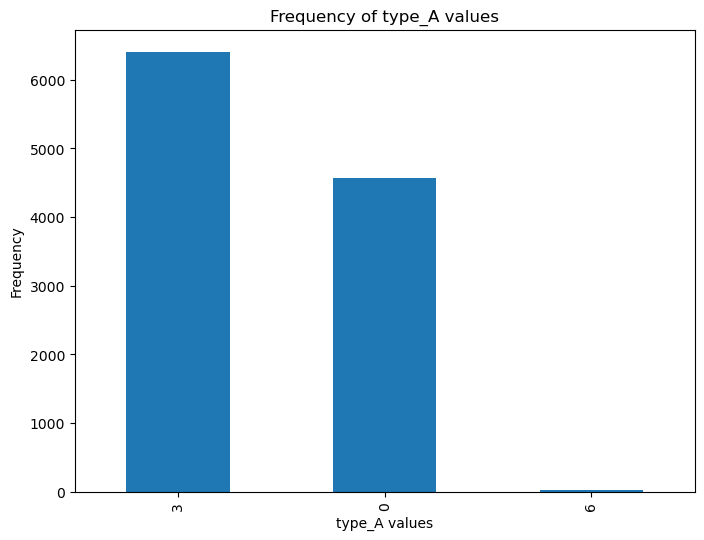

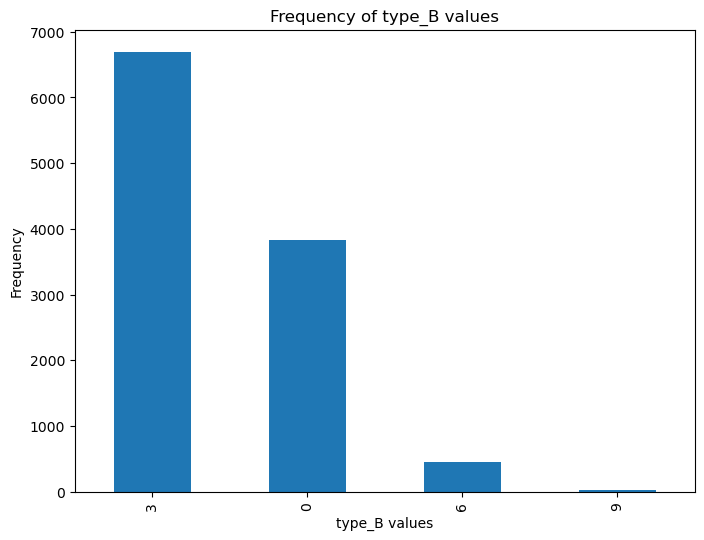

In [115]:
type_A_counts = data['type_A'].value_counts()
type_B_counts = data['type_B'].value_counts()

# Plot bar plots for 'type_A' and 'type_B'
type_A_counts.plot(kind='bar', figsize=(8, 6), title='Frequency of type_A values', xlabel='type_A values', ylabel='Frequency')
plt.show()

type_B_counts.plot(kind='bar', figsize=(8, 6), title='Frequency of type_B values', xlabel='type_B values', ylabel='Frequency')
plt.show()

### Task 7:
Make boxplots of the 'age' attribute for each type of Product B and discuss any conclusions you can
draw from the appearance of the boxplots regarding the ages of customers who purchase different types of
Product B
### Solution 1:

- I used .plot () fucntion along with the attributes of the function such as kind for the two data columns age and type_B.

<Axes: >

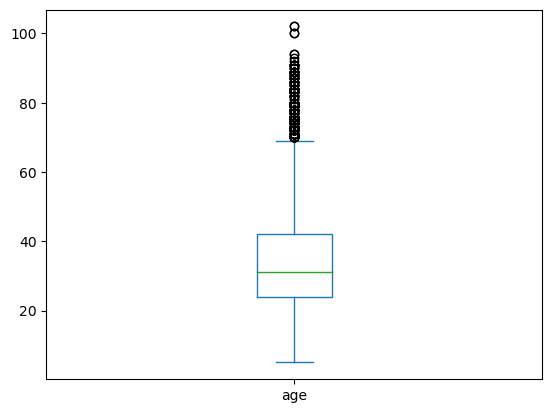

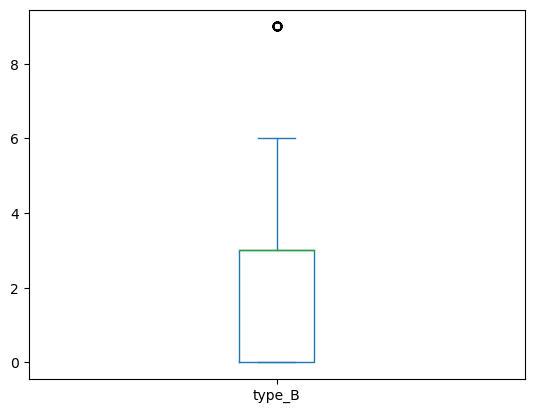

In [123]:
data[['age']].plot(kind = 'box')
data[['type_B']].plot(kind = 'box')


### Solution 2:

- I used .boxplot () fucntion along with the attributes of the function such as kind, figsize to plot the boxplot for the two data columns.
- As boxplot doesn't have the label attribute, I used set_xlabel to label x and y axis externally.

### Conclusions drawn from the Box Plot:

- The 0 type product of Type B is mostly used by age group people who lies between 15 to 70 and median age agoup of people who are using that product mostly lies between 20 to 40 years.
- The 3 type product of Type B is mostly used by age group people who lies between 5 to 65 and median age agoup of people who are using that product mostly are of 15 years.
- The 6 type product of Type B is mostly used by age group people who lies between 25 to 85 and median age agoup of people who are using that product mostly are of 30 years.
- The 9 type product of Type B is mostly used by age group people who lies between 15 to 85 and median age agoup of people who are using that product mostly are of 50 years.

Text(0, 0.5, 'Age')

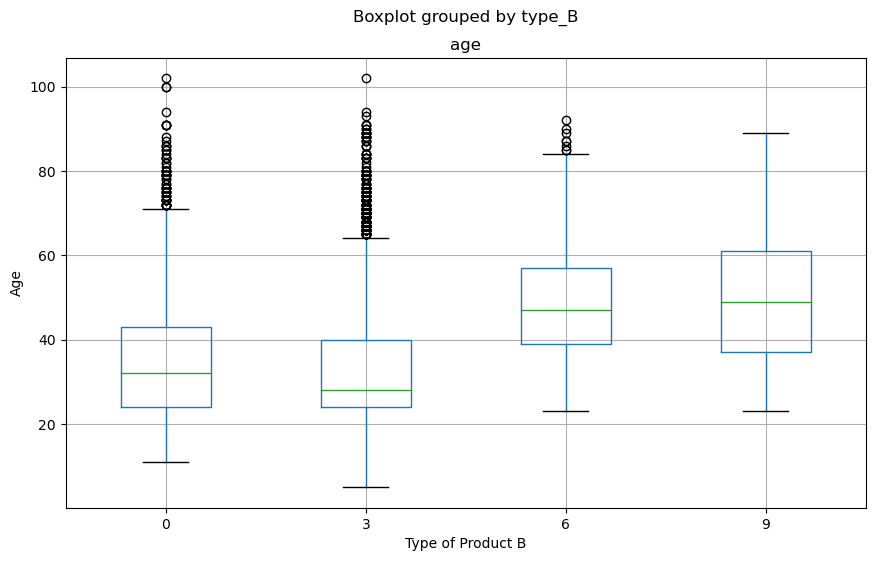

In [121]:
boxplot = data.boxplot(column='age', by='type_B', figsize=(10, 6))

# Set x-label and y-label
boxplot.set_xlabel('Type of Product B')
boxplot.set_ylabel('Age')


### Task 8:

Make histograms of the age and lor_M attributes, and boxplots of the turnover_A, and turnover_B attributes and discuss any conclusions you can draw from the shape of the resulting distributions.


### Solution :

- To get the histogram graph i used .hist() function for age and Lor_M respectively along with figzise attribute in it.
- I used .plot () fucntion along with the attributes of the function such as kind,figsize for the two data columns turnover_A and turnover_B.
- Then i used set_title to keep the title for the graph.

### Conclusions drawn from the Plot:

- From the age histogram we can see that most of the people who are purchasing the product lies between age group of 20 to 30 years.
- From the lor_M histogram we can see that most of the people who are purchasing the product stay with the comapny for 10 to 15 years.


Text(0.5, 1.0, 'boxplots of the turnover_A, and turnover_B')

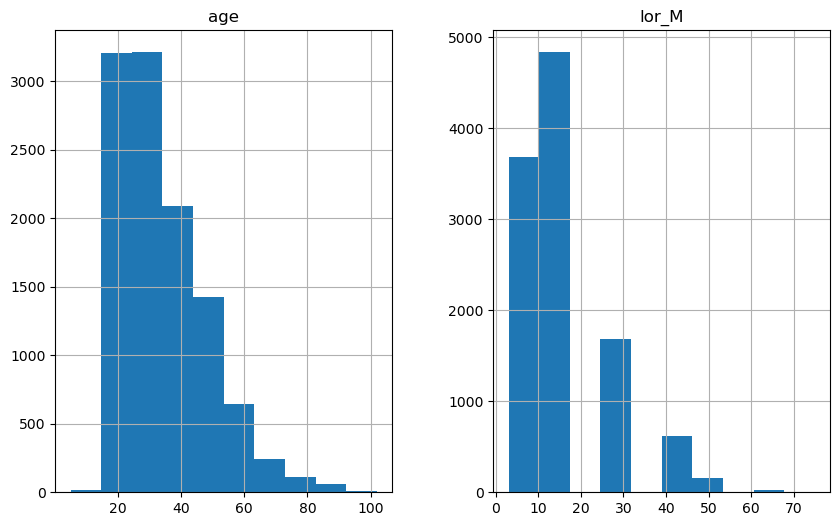

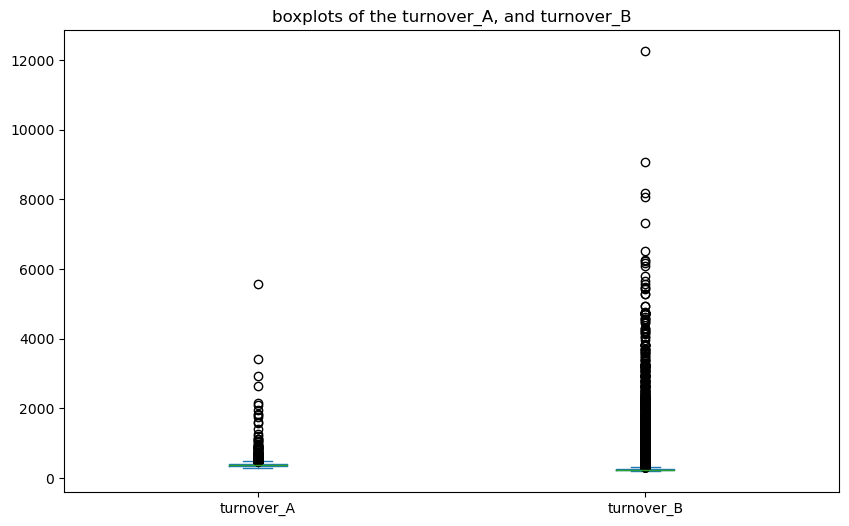

In [138]:
histplot = data[['age', 'lor_M']].hist(figsize=(10, 6))
boxplot = data[['turnover_A', 'turnover_B']].plot(kind='box', figsize=(10, 6))
boxplot.set_title('boxplots of the turnover_A, and turnover_B')

### Task 9:

4 Points) Make a scatter plot of turnover_A vs. lor_M. What can we say about the relationship between those
two attributes?

### Solution :

- To get the scatter graph i used .plot() function for Lor_M, turnover_A and turnover_B respectively along with kind,figzise,title attribute in it.
- The customers who have invested for 10 to 20 months have more turn over.


<Axes: title={'center': 'scatter plot of turnover_A vs. lor_M'}, xlabel='lor_M', ylabel='turnover_A'>

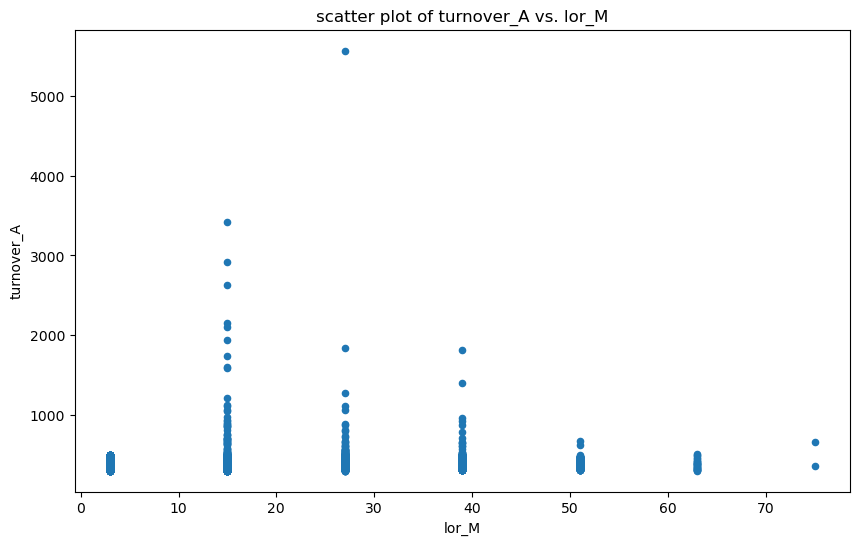

In [135]:
data.plot(x='lor_M', y='turnover_A', kind='scatter', figsize=(10, 6),title='scatter plot of turnover_A vs. lor_M')